Assignmnet no 7.To implement a Federated Learning framework where multiple healthcare institutions
collaboratively train a machine learning model for disease diagnosis or treatment
recommendation without sharing sensitive patient data. (Use Diabetic patient data)

**Install Libraries**

In [ ]:
!pip install torch scikit-learn pandas matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


**Import Dataset,features**

In [2]:
import pandas as pd
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

data = pd.read_csv(url, names=columns)

print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**Preprocessing**

In [6]:
from sklearn.preprocessing import StandardScaler
import torch
from sklearn.model_selection import train_test_split

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Simulate 3 Hospitals**

In [7]:
num_clients = 3
data_per_client = len(X_train) // num_clients

clients = []

for i in range(num_clients):
    start = i * data_per_client
    end = (i+1) * data_per_client
    clients.append((X_train[start:end], y_train[start:end]))

print("Hospitals (clients) created successfully.")


Hospitals (clients) created successfully.


**Define Diagnosis Model**

In [9]:
import torch.nn as nn

class DiabetesModel(nn.Module):
    def __init__(self):
        super(DiabetesModel, self).__init__()
        self.fc1 = nn.Linear(8, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


**Local Training Function (Hospital Side)**

In [15]:
import torch.optim as optim
import torch.nn as nn

def train_client(model, X, y, epochs=5):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    return model.state_dict(), len(X)


**Server-Side Weighted FedAvg**

In [11]:
def weighted_fedavg(client_weights, client_sizes):
    global_weights = copy.deepcopy(client_weights[0])
    total_samples = sum(client_sizes)

    for key in global_weights.keys():
        global_weights[key] = sum(
            client_weights[i][key] * (client_sizes[i] / total_samples)
            for i in range(len(client_weights))
        )

    return global_weights


**Evaluation Function**

In [12]:
def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test).float().mean()
    return accuracy.item() * 100


**Federated Learning Process**

In [16]:
import copy

global_model = DiabetesModel()
rounds = 10
accuracy_list = []

for r in range(rounds):
    print(f"\n--- Communication Round {r+1} ---")

    client_weights = []
    client_sizes = []

    for X_client, y_client in clients:
        local_model = copy.deepcopy(global_model)
        weights, size = train_client(local_model, X_client, y_client)
        client_weights.append(weights)
        client_sizes.append(size)

    # Server aggregation
    global_weights = weighted_fedavg(client_weights, client_sizes)
    global_model.load_state_dict(global_weights)

    # Evaluate global model
    acc = evaluate(global_model, X_test, y_test)
    accuracy_list.append(acc)

    print(f"Global Model Accuracy: {acc:.2f}%")



--- Communication Round 1 ---
Global Model Accuracy: 72.08%

--- Communication Round 2 ---
Global Model Accuracy: 73.38%

--- Communication Round 3 ---
Global Model Accuracy: 74.68%

--- Communication Round 4 ---
Global Model Accuracy: 75.97%

--- Communication Round 5 ---
Global Model Accuracy: 75.32%

--- Communication Round 6 ---
Global Model Accuracy: 75.97%

--- Communication Round 7 ---
Global Model Accuracy: 75.32%

--- Communication Round 8 ---
Global Model Accuracy: 75.97%

--- Communication Round 9 ---
Global Model Accuracy: 75.97%

--- Communication Round 10 ---
Global Model Accuracy: 75.97%


**Plot Accuracy**

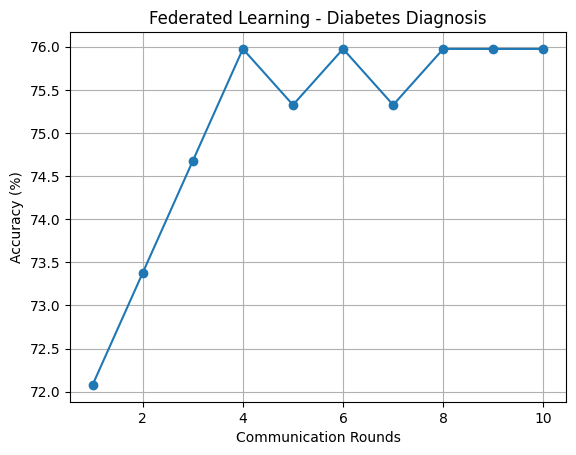

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(1, rounds+1), accuracy_list, marker='o')
plt.title("Federated Learning - Diabetes Diagnosis")
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()
